# 03 — Preprocessing
**Objectif :** Préparer chaque image avant de l'envoyer au CNN.

3 étapes dans l'ordre :
1. **ROI Extraction** — couper uniquement la zone du cerveau
2. **Resize** — standardiser à 240×240×3
3. **Normalisation** — pixels entre 0.0 et 1.0

Puis : **Data Split** — 70% train / 15% val / 15% test

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 1. ROI Extraction — Isoler le cerveau

In [2]:
def crop_brain(image):
    """
    Détecte la zone du cerveau et retourne l'image découpée.
    Le cerveau est la plus grande zone blanche sur fond noir.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Seuillage : séparer cerveau (blanc) du fond (noir)
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    
    # Supprimer le bruit
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    
    # Trouver les contours
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return image
    
    # Garder le plus grand contour = le cerveau
    largest = max(contours, key=cv2.contourArea)
    
    # Bounding box autour du cerveau
    x, y, w, h = cv2.boundingRect(largest)
    
    # Découper la ROI
    roi = image[y:y+h, x:x+w]
    return roi

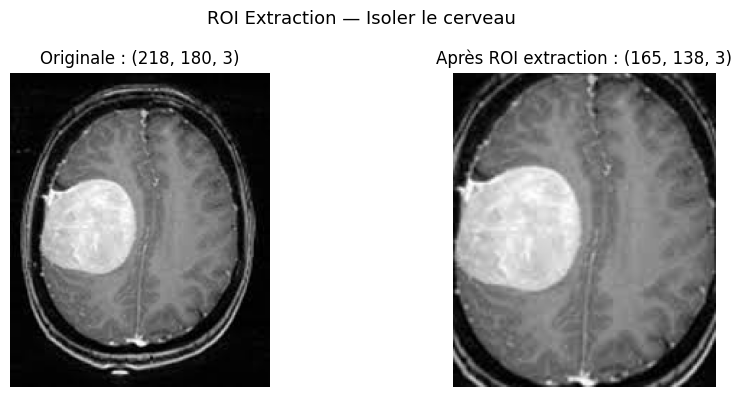

In [3]:
# Visualiser l'effet de la ROI extraction
sample_file = os.listdir('data/augmented_data/yes')[0]
sample_path = os.path.join('data/augmented_data/yes', sample_file)

img_orig = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
img_roi  = crop_brain(img_orig)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_orig)
axes[0].set_title(f'Originale : {img_orig.shape}')
axes[0].axis('off')
axes[1].imshow(img_roi)
axes[1].set_title(f'Après ROI extraction : {img_roi.shape}')
axes[1].axis('off')
plt.suptitle('ROI Extraction — Isoler le cerveau', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Pipeline complet : ROI + Resize + Normalisation

In [4]:
IMG_SIZE = (240, 240)

def preprocess_image(img_path):
    """
    Pipeline complet pour une image :
    1. Lecture
    2. ROI extraction
    3. Resize 240x240
    4. Normalisation 0-1
    """
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_brain(img)             # étape 1 : ROI
    img = cv2.resize(img, IMG_SIZE)   # étape 2 : resize
    img = img / 255.0                 # étape 3 : normalisation
    return img

## 3. Charger toutes les images et créer X, y

In [5]:
X = []
y = []

for label, value in [('yes', 1), ('no', 0)]:
    folder = os.path.join('data', 'augmented_data', label)
    files = os.listdir(folder)
    print(f'Chargement {label} : {len(files)} images...')
    for f in files:
        path = os.path.join(folder, f)
        img = preprocess_image(path)
        X.append(img)
        y.append(value)

X = np.array(X)
y = np.array(y)

print(f'\nX shape : {X.shape}')   # (2065, 240, 240, 3)
print(f'y shape : {y.shape}')   # (2065,)
print(f'Pixels min/max : {X.min():.2f} / {X.max():.2f}')  # 0.0 / 1.0

Chargement yes : 1085 images...
Chargement no : 784 images...

X shape : (1869, 240, 240, 3)
y shape : (1869,)
Pixels min/max : 0.00 / 1.00


## 4. Data Split — 70% / 15% / 15%

In [6]:
# Split 1 : 70% train, 30% temporaire
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Split 2 : 30% temporaire → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train      : {X_train.shape[0]} images')
print(f'Validation : {X_val.shape[0]} images')
print(f'Test       : {X_test.shape[0]} images')

Train      : 1308 images
Validation : 280 images
Test       : 281 images


## 5. Sauvegarder les données préprocessées

In [7]:
np.save('data/X_train.npy', X_train)
np.save('data/X_val.npy',   X_val)
np.save('data/X_test.npy',  X_test)
np.save('data/y_train.npy', y_train)
np.save('data/y_val.npy',   y_val)
np.save('data/y_test.npy',  y_test)

print('Données sauvegardées dans data/')
print('=> Prêt pour le notebook 04_model_training.ipynb')

Données sauvegardées dans data/
=> Prêt pour le notebook 04_model_training.ipynb
